In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/diabetes_binary_health_indicators_BRFSS2015.csv', nrows=80000)

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Done!")

Train size: (64000, 21)
Test size: (16000, 21)
Done!


In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())
print("Done!")

Before SMOTE: {0.0: 55250, 1.0: 8750}
After SMOTE: {0.0: 55250, 1.0: 55250}
Done!


In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_bal, y_train_bal)

lr_pred = lr.predict(X_test)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

print("LOGISTIC REGRESSION RESULTS")
print("="*40)
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC Score: {lr_auc:.4f}")

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82     13813
         1.0       0.30      0.76      0.43      2187

    accuracy                           0.72     16000
   macro avg       0.63      0.74      0.62     16000
weighted avg       0.86      0.72      0.77     16000

ROC-AUC Score: 0.8147


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("RANDOM FOREST RESULTS")
print("="*40)
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC Score: {rf_auc:.4f}")

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     13813
         1.0       0.46      0.18      0.26      2187

    accuracy                           0.86     16000
   macro avg       0.67      0.57      0.59     16000
weighted avg       0.82      0.86      0.83     16000

ROC-AUC Score: 0.7925


In [8]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train_bal, y_train_bal)

xgb_pred = xgb.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

print("XGBOOST RESULTS")
print("="*40)
print(classification_report(y_test, xgb_pred))
print(f"ROC-AUC Score: {xgb_auc:.4f}")

XGBOOST RESULTS
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.93     13813
         1.0       0.51      0.18      0.27      2187

    accuracy                           0.86     16000
   macro avg       0.70      0.58      0.60     16000
weighted avg       0.83      0.86      0.84     16000

ROC-AUC Score: 0.8170


                 Model  ROC-AUC  Accuracy  Diabetic Recall
0  Logistic Regression   0.8147      0.72             0.76
1        Random Forest   0.7925      0.86             0.18
2              XGBoost   0.8170      0.86             0.18


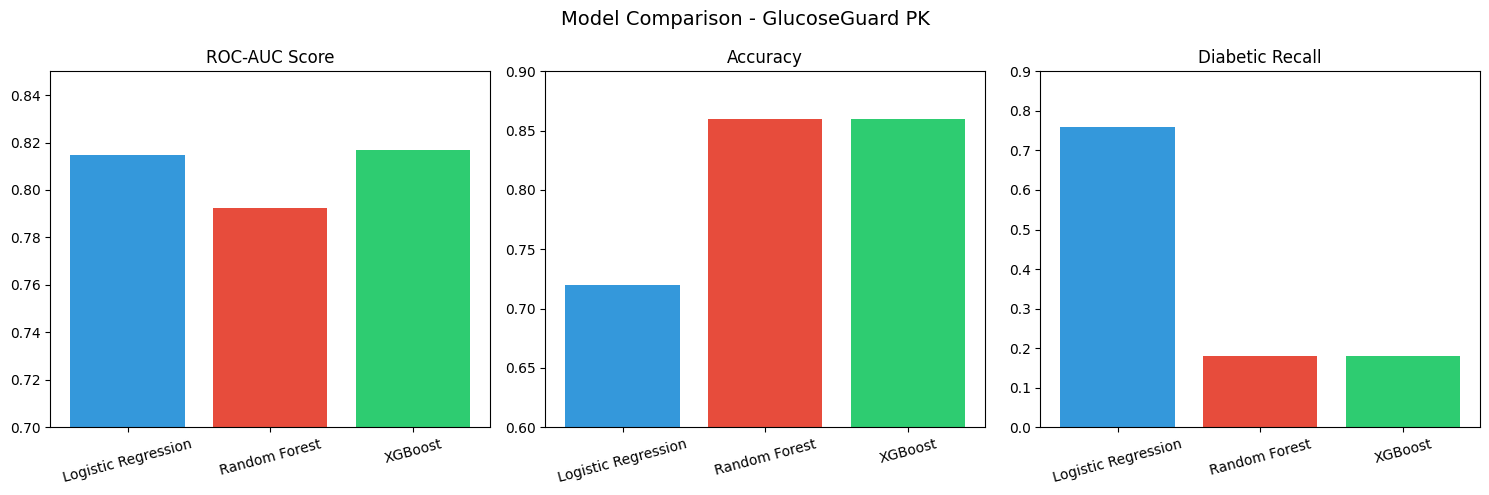

In [9]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [0.8147, 0.7925, 0.8170],
    'Accuracy': [0.72, 0.86, 0.86],
    'Diabetic Recall': [0.76, 0.18, 0.18]
}

results_df = pd.DataFrame(results)
print(results_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(results['Model'], results['ROC-AUC'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('ROC-AUC Score')
axes[0].set_ylim(0.7, 0.85)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results['Model'], results['Accuracy'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('Accuracy')
axes[1].set_ylim(0.6, 0.9)
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(results['Model'], results['Diabetic Recall'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_title('Diabetic Recall')
axes[2].set_ylim(0, 0.9)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison - GlucoseGuard PK', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
import joblib

joblib.dump(lr, '../models/glucoseguard_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [11]:
import joblib

joblib.dump(lr, '../models/glucoseguard_model.pkl')
joblib.dump(X_train.columns.tolist(), '../models/feature_names.pkl')
print("Model saved!")
print("Features saved!")

Model saved!
Features saved!
